In [1]:
import json
import os
import sys
import time
import warnings
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import pysam
import pyfaidx 
import pyranges as pr
import tensorflow as tf
import models as mo
import process as pr
%load_ext autoreload


from baskerville import seqnn
from baskerville import gene as bgene
from baskerville import dna

sys.path.insert(0,'/Users/k2585057/borzoi/')
from examples.borzoi_helpers import *

tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

bz_path = '/Users/k2585057/Dropbox/PhD/Analysis/Project/GENOME_PREDICT/models/borzoi/'
gn_path = '/Users/k2585057/Dropbox/PhD/Analysis/Project/GENOME/'

/Users/k2585057/anaconda3/envs/borzoi_x86/lib/python3.10/site-packages/pyranges/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import platform
platform.platform(), os.uname()

('macOS-15.7.2-arm64-i386-64bit',
 posix.uname_result(sysname='Darwin', nodename='KCLMRYM6JWW4M', release='24.6.0', version='Darwin Kernel Version 24.6.0: Wed Oct 15 21:12:15 PDT 2025; root:xnu-11417.140.69.703.14~1/RELEASE_ARM64_T6041', machine='arm64'))

# Load in model and annotations

In [2]:
#load annotations
#===================================
#Load in hg38 fasta 
fa = pysam.Fastafile(f'{gn_path}/annotations/hg38/assembly/ucsc/hg38.fa')

#Load hg38 GTF - expand to complete GTF!!!!
gtf = bgene.Transcriptome(f'{gn_path}/annotations/hg38/genes/gencode41/gencode41_basic_nort.gtf')

In [3]:
fa.references[:10]

['chr1',
 'chr10',
 'chr11',
 'chr11_KI270721v1_random',
 'chr12',
 'chr13',
 'chr14',
 'chr14_GL000009v2_random',
 'chr14_GL000225v1_random',
 'chr14_KI270722v1_random']

In [4]:
fa.fetch('chr1', 10000, 10050)

'taaccctaaccctaaccctaaccctaaccctaaccctaaccctaacccta'

In [20]:
gtf.genes['ENSG00000223972.5'].__dict__

{'chrom': 'chr1',
 'strand': '+',
 'kv': {'gene_id': 'ENSG00000223972.5',
  'transcript_id': 'ENST00000456328.2',
  'gene_type': 'transcribed_unprocessed_pseudogene',
  'gene_name': 'DDX11L1',
  'transcript_type': 'processed_transcript',
  'transcript_name': 'DDX11L1-202',
  'exon_number': '1',
  'exon_id': 'ENSE00002234944.1',
  'level': '2',
  'transcript_support_level': '1',
  'hgnc_id': 'HGNC:37102',
  'tag': 'basic',
  'havana_gene': 'OTTHUMG00000000961.2',
  'havana_transcript': 'OTTHUMT00000362751.1'},
 'name': 'DDX11L1',
 'exons': IntervalTree([Interval(11868, 12227, True), Interval(12009, 12057, True), Interval(12178, 12227, True), Interval(12612, 12697, True), Interval(12612, 12721, True), Interval(12974, 13052, True), Interval(13220, 13374, True), Interval(13220, 14409, True), Interval(13452, 13670, True)])}

In [3]:
#Load Borzoi 
seq_len = 524288
models = mo.borzoi_load(n_folds=1, seq_len=seq_len, rc=True)

# Make predictions

In [6]:
#Prediction
#==================

#Define location
chrom = 'chr2'
#search_gene = 'ENSG00000144285.23' #ADD IN LATER! 
center_pos = 166_060_000 # middle position for prediction - NB normally use location to mutate

#1hot encode
wt_hot, start  = pr.onehot(fa=fa, chrom = 'chr2', center_pos = 166_060_000, seq_len = seq_len)

#mutate
out = predict_tracks(models, wt_hot)

In [24]:
wt_hot

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       ...,
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.]], dtype=float32)

In [9]:
%autoreload
#MUTATE + PREDICT
#=======================

#parameters for mutation
poses = [166149022] #absolute positions of mutation
alts = ['C'] #change to nt.
chrs = ['chr2']

#1hot encode
wt_hot, start  = pr.onehot(fa=fa, chrom = chrs[0], center_pos = poses[0], seq_len = seq_len)
#mutate
mt_hot = pr.mutate(wt_hot, poses, start, alts)

In [10]:
#sanity check - double check mutation!
#===================
#to access position - subtract 1 as poses is 1 base!!!!
wt_hot[poses[0] - start-1], mt_hot[poses[0] - start-1]

(array([0., 0., 0., 1.], dtype=float32),
 array([0., 1., 0., 0.], dtype=float32))

In [11]:
# predict
wt_pred = predict_tracks(models, wt_hot)
mt_pred = predict_tracks(models, mt_hot)

In [32]:
wt_pred[0,0,:,0]

array([0.03073, 0.03345, 0.0294 , ..., 0.04037, 0.03955, 0.03436],
      dtype=float16)

In [32]:
#compare outputs

array([[[[0.03073, 0.1212 , 0.1309 , ..., 0.1162 , 0.1094 , 0.08966],
         [0.03345, 0.12366, 0.1322 , ..., 0.1203 , 0.1123 , 0.0946 ],
         [0.0294 , 0.112  , 0.1172 , ..., 0.0989 , 0.0973 , 0.08856],
         ...,
         [0.04037, 0.1725 , 0.1881 , ..., 0.128  , 0.1643 , 0.126  ],
         [0.03955, 0.1702 , 0.1797 , ..., 0.1282 , 0.1617 , 0.122  ],
         [0.03436, 0.1492 , 0.1532 , ..., 0.11053, 0.1382 , 0.10736]]]],
      dtype=float16)

In [33]:
# region_start = 
# region_end = 

brain_expression(wt_pred, mt_pred, start, start + 200, start + 800)

(2191.0918386358962, 2192.0053582442433, 0.9135196083470873)

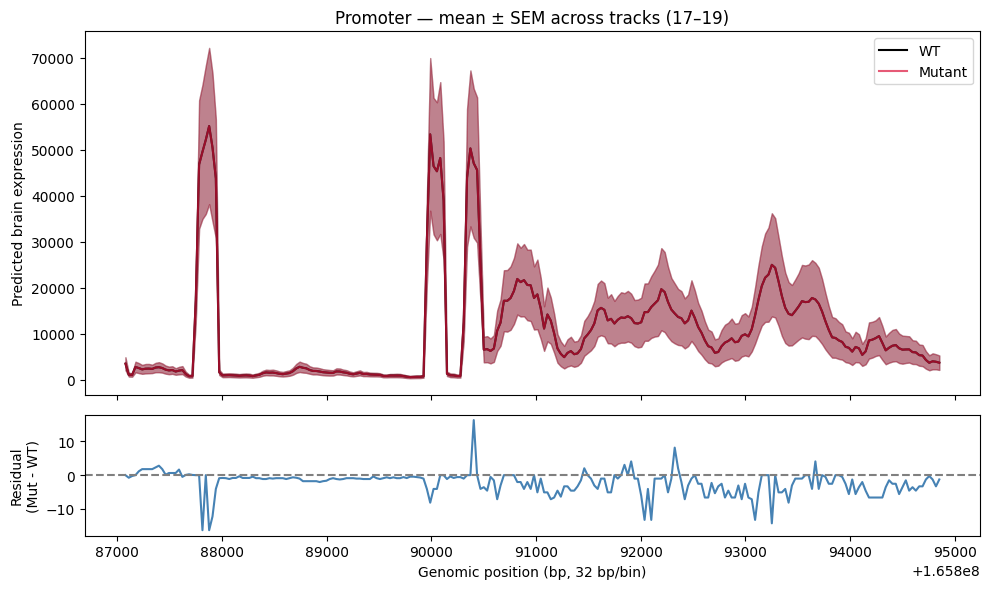

In [23]:
plot_brain_tracks([wt_pred], [mt_pred],start, start + 200, start + 8000)

In [18]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def plot_brain_tracks(y_wt_list, y_mut_list, start,
                      window_start, window_end,
                      bp_per_bin=32,
                      scale=100000,
                      window_name="Promoter"):
    """
    Plot mean±SEM of predicted brain-track (17–19) expression across a genomic window,
    comparing WT vs Mutant across model folds, plus residual (Mut-WT).

    Parameters
    ----------
    y_wt_list, y_mut_list : list of tensors/arrays
        Each element shape ~ [1, 1, positions, tracks].
    start : int
        Absolute genomic coordinate of the start of the model input sequence.
    window_start, window_end : int
        Absolute genomic coordinates defining the plotting window.
    bp_per_bin : int, default=32
        Genomic bases per output bin (Borzoi default = 32).
    scale : int, default=100000
        Scaling factor for expression (Borzoi convention).
    window_name : str
        Label for the plot title.
    """

    brain_tracks = slice(17, 20)

    def _to_np(y):
        return y.numpy() if isinstance(y, tf.Tensor) else y

    def _extract_positions_mean(y):
        """Return mean expression (across brain tracks) per bin within window."""
        arr = _to_np(y)[0, 0]  # shape: (positions, tracks)

        start_bin = max(0, (window_start - start) // bp_per_bin)
        end_bin   = min(arr.shape[0], (window_end - start) // bp_per_bin)

        brain_data = arr[start_bin:end_bin, brain_tracks] * scale
        return brain_data.mean(axis=-1)  # mean across tracks → (L,)

    # Stack across folds: (n_folds, L)
    wt_mat = np.stack([_extract_positions_mean(y) for y in y_wt_list], axis=0)
    mut_mat = np.stack([_extract_positions_mean(y) for y in y_mut_list], axis=0)

    # Compute mean and SEM
    wt_mean, mut_mean = wt_mat.mean(axis=0), mut_mat.mean(axis=0)
    wt_sem  = wt_mat.std(axis=0, ddof=1) / np.sqrt(wt_mat.shape[0]) if wt_mat.shape[0] > 1 else np.zeros_like(wt_mean)
    mut_sem = mut_mat.std(axis=0, ddof=1) / np.sqrt(mut_mat.shape[0]) if mut_mat.shape[0] > 1 else np.zeros_like(mut_mean)
    residual_mean = mut_mean - wt_mean

    # X-axis in absolute genomic coordinates
    x_bp = np.arange(window_start, window_end, bp_per_bin)[:len(wt_mean)]

    # --- Plot ---
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 6), sharex=True,
        gridspec_kw={'height_ratios': [3, 1]}
    )

    # Top: WT vs Mut
    ax1.plot(x_bp, wt_mean, label='WT', color='black')
    ax1.fill_between(x_bp, wt_mean - wt_sem, wt_mean + wt_sem, alpha=0.3, color='black')
    ax1.plot(x_bp, mut_mean, label='Mutant', color='crimson', alpha=0.7)
    ax1.fill_between(x_bp, mut_mean - mut_sem, mut_mean + mut_sem, alpha=0.3, color='crimson')
    ax1.set_ylabel('Predicted brain expression')
    ax1.set_title(f"{window_name} — mean ± SEM over {wt_mat.shape[0]} folds")
    ax1.legend()

    # Bottom: Residual (Mut - WT)
    ax2.plot(x_bp, residual_mean, color='steelblue')
    ax2.axhline(0, linestyle='--', color='gray', linewidth=1.5)
    ax2.set_ylabel('Residual\n(Mut - WT)')
    ax2.set_xlabel(f'Genomic position (bp, {bp_per_bin} bp/bin)')

    plt.tight_layout()
    plt.show()


In [16]:
import tensorflow as tf

def brain_expression(y_wt, y_mut, start, window_start, window_end, bin_size=32, scale=100000):
    """
    Compute mean brain expression (tracks 17–19) across a genomic window.

    Parameters
    ----------
    y_wt, y_mut : np.ndarray or tf.Tensor
        Model outputs for wildtype and mutant sequences, shape (1, 1, seq_bins, n_tracks).
    start : int
        Genomic coordinate of the start of the input sequence.
    window_start, window_end : int
        Genomic coordinates of the region of interest.
    bin_size : int, default=32
        Number of base pairs per model output bin (Borzoi default = 32 bp).
    scale : int, default=100000
        Scaling factor for expression (matches Borzoi convention).

    Returns
    -------
    wt_mean, mut_mean, delta : tuple[float]
        Mean wildtype, mean mutant, and (mut - wt) mean expression across brain tracks.
    """
    # Brain track indices (inclusive range 17:19)
    brain_tracks = slice(17, 20)

    # Convert genomic coordinates to output bins
    start_bin = max(0, (window_start - start) // bin_size)
    end_bin   = min(y_wt.shape[2], (window_end - start) // bin_size)

    # Slice predictions
    wt_brain = scale * y_wt[:, :, start_bin:end_bin, brain_tracks]
    mut_brain = scale * y_mut[:, :, start_bin:end_bin, brain_tracks]

    # Compute mean expression
    wt_mean = tf.reduce_mean(wt_brain)
    mut_mean = tf.reduce_mean(mut_brain)
    delta = mut_mean - wt_mean

    return wt_mean.numpy(), mut_mean.numpy(), delta.numpy()


In [ ]:
#Define start and end indeces for expression estimation
start_trim = 169000 // 32
end_trim = (166175000 - start) // 32
start_trim, end_trim

y_mut = predict_tracks(models, new_one_hot)
brain_mut = 100000 * y_mut[:, :, start_trim:end_trim, 17:20] #17, 18, 19 are the brain tracks
mut_sum = int(tf.reduce_sum(brain_mut))/100000

df = pd.read_excel('/Users/k2585057/Dropbox/PhD/Analysis/Project/SCN1A_PREDICT/BORZOI/oscars_top3.xlsx')
prom_l = np.concatenate((['A']*4, ['B1']*4, ['B2']*4))
prom = prom_l[0]
model = models[0]
curr_df = df[(df['Name'] == prom)  & (df['Use']=='Y')].set_index('Position')
alts  = curr_df['Mutation'].tolist()
poses = curr_df.index.tolist()
#mutate
mut_code = mutate(wt_code, poses, start, alts)
#predict
#y_mut = predict_tracks([model], mut_code)

In [10]:
def expression(y_wt, y_mut):
    start_trim = 169000 // 32                      # 5281
    end_trim   = (166175000 - start) // 32         # 11785
    brain_tracks = [17, 18, 19]
    wt_sum  = tf.reduce_sum(y_wt[:, :, start_trim:end_trim, brain_tracks])
    mut_sum = tf.reduce_sum(y_mut[:, :, start_trim:end_trim, brain_tracks])
    return(wt_sum, mut_sum)
    #sum over tissue

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def plot_brain_tracks(y_wt_list, y_mut_list, start,
                      brain_tracks=(17, 18, 19),
                      bp_per_bin=32,
                      start_bp=169000,
                      end_bp_abs=166175000,
                      window_name="Promoter"):
    """
    Plot mean±SEM of predicted brain-track expression across the genomic window,
    comparing WT vs Mutant across model folds, plus residual (Mut-WT).

    Parameters
    ----------
    y_wt_list, y_mut_list : list of tensors/arrays
        Each element shape ~ [1, 1, positions, tracks]
    start : int
        Genomic start coordinate used to build the input window.
    brain_tracks : tuple/list of int
        Track indices to aggregate (e.g., brain-related tracks).
    bp_per_bin : int
        Genomic bases represented by one output bin (typically 32).
    start_bp : int
        Left boundary (in bp) of the evaluation window relative to 'start'.
    end_bp_abs : int
        Absolute genomic coordinate of the right boundary (in bp).
    window_name : str
        Title label.

    Returns
    -------
    None (plots figure)
    """

    # Compute bin indices for the evaluation window
    start_trim = start_bp // bp_per_bin
    end_trim   = (end_bp_abs - start) // bp_per_bin  # assumes 'start' is absolute

    def _to_np(y):
        return y.numpy() if isinstance(y, tf.Tensor) else y

    def _extract_positions_mean(y):
        """
        Returns a vector (length L) of mean signal across selected tracks at each position.
        """
        arr = _to_np(y)
        # Slice positions window: keep tracks axis as the last axis
        # Expected arr shape: [1, 1, positions, tracks]
        arr = arr[0, 0, start_trim:end_trim, :]  # shape (L, tracks)
        # Select tracks while preserving axis order
        arr = np.take(arr, indices=brain_tracks, axis=-1)  # shape (L, len(tracks))
        # Mean across tracks -> shape (L,)
        return arr.mean(axis=-1)

    # Stack folds: shape (n_folds, L)
    wt_mat  = np.stack([_extract_positions_mean(y) for y in y_wt_list], axis=0)
    mut_mat = np.stack([_extract_positions_mean(y) for y in y_mut_list], axis=0)

    # Mean and SEM across folds
    wt_mean, mut_mean = wt_mat.mean(axis=0), mut_mat.mean(axis=0)
    wt_sem  = wt_mat.std(axis=0, ddof=1) / np.sqrt(wt_mat.shape[0]) if wt_mat.shape[0] > 1 else np.zeros_like(wt_mean)
    mut_sem = mut_mat.std(axis=0, ddof=1) / np.sqrt(mut_mat.shape[0]) if mut_mat.shape[0] > 1 else np.zeros_like(mut_mean)

    residual_mean = mut_mean - wt_mean

    # X-axis in bins (each ~32bp). If you prefer bp coordinates, uncomment the bp line.
    x_bins = np.arange(start_trim, end_trim)
    # x_bp = start + x_bins * bp_per_bin  # absolute genomic bp

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Top: WT vs Mutant with SEM bands
    ax1.plot(x_bins, wt_mean, label='WT', c = 'k')
    ax1.fill_between(x_bins, wt_mean - wt_sem, wt_mean + wt_sem, alpha=0.3)
    ax1.plot(x_bins, mut_mean, label='Mutant', c='crimson', alpha=0.4)
    ax1.fill_between(x_bins, mut_mean - mut_sem, mut_mean + mut_sem, alpha=0.3)
    ax1.set_ylabel('Predicted brain expression')
    ax1.set_title(f"{window_name} — mean ± SEM over {wt_mat.shape[0]} folds")
    ax1.legend()

    # Bottom: Residual
    ax2.plot(x_bins, residual_mean)
    ax2.axhline(0, linestyle='--', linewidth=2)
    ax2.set_ylabel('Residual\n(Mut - WT)')
    ax2.set_xlabel('Output bin ({} bp/bin)'.format(bp_per_bin))

    plt.tight_layout()
    plt.show()

In [ ]:
# Run prediction

In [ ]:
# Output

In [ ]:
# add in other functions